# Data Mining I - Lab 02

## Imports

It is important to have the imports at the top in order to mantain everything organized and so that any user is able to quicly check what packages are necessary to run this notebook.

In [1]:
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import math
from scipy import stats
import numpy as np

from datetime import datetime

from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer

## Data Loading

In [2]:
df_original = pd.read_csv("https://raw.githubusercontent.com/fpontejos/DM1_2324/main/data/datamining.csv")

In [3]:
df_original.head()

,Unnamed: 0,age,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description
0,0,1946,90782.0,33,66,1402,37,5,44,10,3,0.0,19,M,Graduation,Together,Take my money!!
1,1,1936,113023.0,32,6,1537,55,1,38,4,2,0.0,9,F,PhD,Divorced,Take my money!!
2,2,1990,28344.0,11,69,44,32,19,24,1,24,1.0,59,M,Graduation,Married,Kind of OK
3,3,1955,93571.0,26,10,888,60,10,19,6,5,1.0,35,F,Master,NaN,OK nice!
4,4,1955,91852.0,31,26,1138,59,5,28,4,4,1.0,34,F,Graduation,Together,Take my money!!


It is a good practice to make a copy of the original data source, that way, if anything happens, we can always go back to the original data.

In [4]:
df = df_original.copy()

## Metadata

| **Feature**         | **Description**                                                  |
|-----------------------|------------------------------------------------------------------|
| *id*                  | The unique identifier of the customer                            |
| *age*                 | The year of birth of the customer                                |
| *income*              | The income of the customer                                       |
| *frq*                 | Frequency: number of purchases made by the customer              |
| *rcn*                 | Recency: number of days since last customer purchase             |
| *mnt*                 | Monetary: amount of € spent by the customer in purchases         |
| *clothes*             | Number of clothes items purchased by the customer                |
| *kitchen*             | Number of kitchen items purchased by the customer                |
| *small_appliances*    | Number of small_appliances items purchased by the customer       |
| *toys*                | Number of toys items purchased by the customer                   |
| *house_keeping*       | Number of house_keeping items purchased by the customer          |
| *dependents*          | Binary. Whether or not the customer has dependents               |
| *per_net_purchase*    | Percentage of purchases made online                              |
| *education*           | Education level of the customer                                  |
| *status*              | Marital status of the customer                                   |
| *gender*              | Gender of the customer                                           |
| *description*         | Last customer's recommendation description                       |


## Initial Analysis

In [5]:
df.dtypes

Unnamed: 0            int64
age                   int64
income              float64
frq                   int64
rcn                   int64
mnt                   int64
clothes               int64
kitchen               int64
small_appliances      int64
toys                  int64
house_keeping         int64
dependents          float64
per_net_purchase      int64
gender               object
education            object
status               object
description          object
dtype: object

As we can see the "dependents" feature is being treated as a decimal number (float), we should change it to a boolean to avoid certain incoherences in our data.

In [6]:
df["dependents"] = df["dependents"].astype("boolean")

In [7]:
df.dtypes

Unnamed: 0            int64
age                   int64
income              float64
frq                   int64
rcn                   int64
mnt                   int64
clothes               int64
kitchen               int64
small_appliances      int64
toys                  int64
house_keeping         int64
dependents          boolean
per_net_purchase      int64
gender               object
education            object
status               object
description          object
dtype: object

We should also change the name of some columns, like age and id.

In [8]:
df = df.rename(columns={"Unnamed: 0" : "id", "age" : "birth_year"})

In [9]:
df.head()

,id,birth_year,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description
0,0,1946,90782.0,33,66,1402,37,5,44,10,3,False,19,M,Graduation,Together,Take my money!!
1,1,1936,113023.0,32,6,1537,55,1,38,4,2,False,9,F,PhD,Divorced,Take my money!!
2,2,1990,28344.0,11,69,44,32,19,24,1,24,True,59,M,Graduation,Married,Kind of OK
3,3,1955,93571.0,26,10,888,60,10,19,6,5,True,35,F,Master,NaN,OK nice!
4,4,1955,91852.0,31,26,1138,59,5,28,4,4,True,34,F,Graduation,Together,Take my money!!


We are now able to make a simple describe() of our data to check some important metrics.

In here different data types give different metrics, showing the importance of why we should change the data types of our features.

In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,8998.0,NaN,NaN,NaN,4498.5,2597.643195,0.0,2249.25,4498.5,6747.75,8997.0
birth_year,8998.0,NaN,NaN,NaN,1966.05968,17.296552,1936.0,1951.0,1966.0,1981.0,1996.0
income,8952.0,NaN,NaN,NaN,69963.550827,27591.556226,10000.0,47741.0,70030.5,92218.0,140628.0
frq,8998.0,NaN,NaN,NaN,19.848077,10.903435,3.0,10.0,17.0,28.0,59.0
rcn,8998.0,NaN,NaN,NaN,62.469771,69.761802,0.0,26.0,53.0,79.0,549.0
mnt,8998.0,NaN,NaN,NaN,622.162814,646.768205,6.0,63.0,383.0,1076.0,3052.0
clothes,8998.0,NaN,NaN,NaN,50.446655,23.422249,1.0,33.0,51.0,69.0,99.0
kitchen,8998.0,NaN,NaN,NaN,7.039675,7.848139,0.0,2.0,4.0,10.0,75.0
small_appliances,8998.0,NaN,NaN,NaN,28.524116,12.586437,1.0,19.0,28.0,37.0,74.0
toys,8998.0,NaN,NaN,NaN,7.036897,7.924422,0.0,2.0,4.0,10.0,62.0


### Missing Values

In [11]:
df.isna().sum()

id                    0
birth_year            0
income               46
frq                   0
rcn                   0
mnt                   0
clothes               0
kitchen               0
small_appliances      0
toys                  0
house_keeping         0
dependents          282
per_net_purchase      0
gender                0
education            47
status              177
description           0
dtype: int64

We can also check the percentage of missing values.

In [12]:
(df.isna().sum() / len(df) * 100).round(2).astype("str") + " %"

id                   0.0 %
birth_year           0.0 %
income              0.51 %
frq                  0.0 %
rcn                  0.0 %
mnt                  0.0 %
clothes              0.0 %
kitchen              0.0 %
small_appliances     0.0 %
toys                 0.0 %
house_keeping        0.0 %
dependents          3.13 %
per_net_purchase     0.0 %
gender               0.0 %
education           0.52 %
status              1.97 %
description          0.0 %
dtype: object

And the total missing values.

In [13]:
df.isna().sum().sum()

np.int64(552)

### Duplicated Values

In [14]:
df.duplicated().sum()

np.int64(0)

In our case, since we have an id, it is crucial to make sure that we don't have 2 customers with the same id.

In [15]:
df["id"].duplicated().sum()

np.int64(0)

We don't have duplicated rows, or customers with the same id, but what if we did?

In [16]:
df.loc[len(df)] = df.iloc[-1]
df.tail()

,id,birth_year,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description
8994,8994,1975,58121.0,12,6,61,53,6,28,7,6,True,71,M,2nd Cycle,Single,Meh...
8995,8995,1986,54292.0,29,72,1011,41,11,36,1,11,False,31,M,Graduation,Together,Take my money!!
8996,8996,1938,125962.0,38,75,1668,61,2,25,5,6,True,45,M,2nd Cycle,Married,Take my money!!
8997,8997,1994,26385.0,9,24,46,5,13,21,46,15,True,52,M,1st Cycle,Single,Kind of OK
8998,8997,1994,26385.0,9,24,46,5,13,21,46,15,True,52,M,1st Cycle,Single,Kind of OK


In [17]:
df.duplicated().sum()

np.int64(1)

In [18]:
df[df.duplicated()]

,id,birth_year,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description
8998,8997,1994,26385.0,9,24,46,5,13,21,46,15,True,52,M,1st Cycle,Single,Kind of OK


This will keep the first occurrence

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df.duplicated().sum()

np.int64(0)

## Numerical/Categorical Split

Data is separated into 2 big groups, Categorical (non-metric or qualitative) and Numerical (metric or quantitative).

In [21]:
categorical = ["education", "status", "gender", "dependents", "description"]

numerical = ["birth_year", "income", "frq", "rcn", "mnt", "clothes", "kitchen", "small_appliances", "toys", "house_keeping", "per_net_purchase"]

## Data Visualization

In [22]:
sns.set(style="darkgrid")

### Histplots

A great way to verify the distribution of the various numerical features.

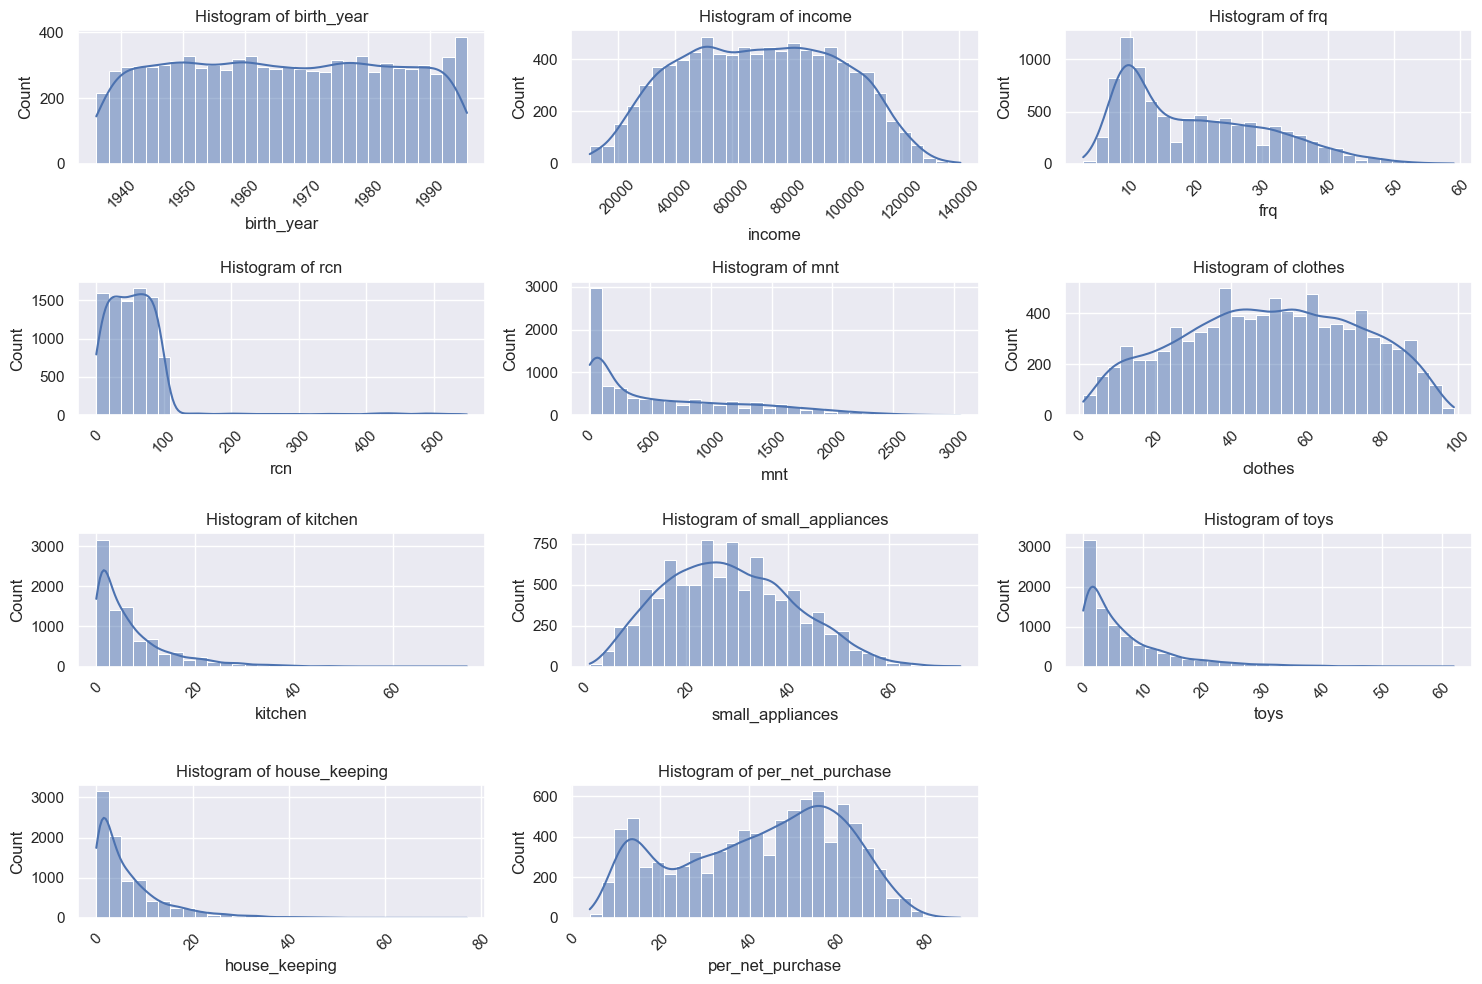

In [23]:
cols = 3
rows = math.ceil(len(numerical) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(numerical):
    sns.histplot(x=df[feature], ax=axes[i], kde=True, bins=30)
    axes[i].set_title(f"Histogram of {feature}")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Boxplots

Gives us some insights regarding the quartiles of the data and also the possible outliers.

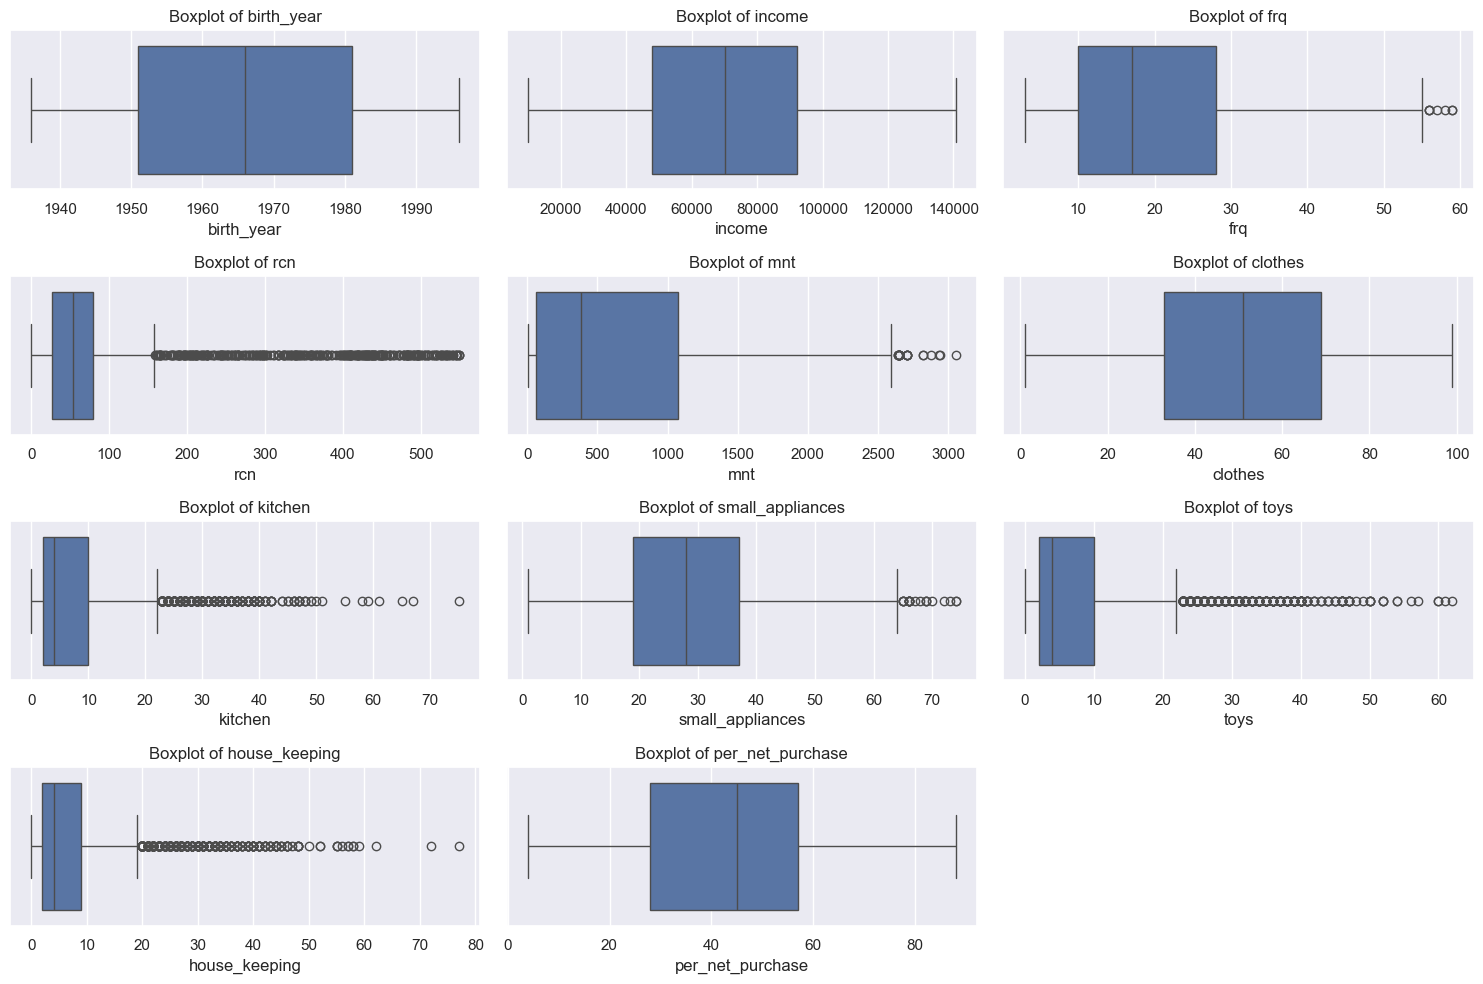

In [24]:
cols = 3
rows = math.ceil(len(numerical) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(numerical):
    sns.boxplot(x=df[feature], ax=axes[i])
    axes[i].set_title(f"Boxplot of {feature}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Countplots

Useful to verify the frequency of each category and the imbalances of the categorical features.

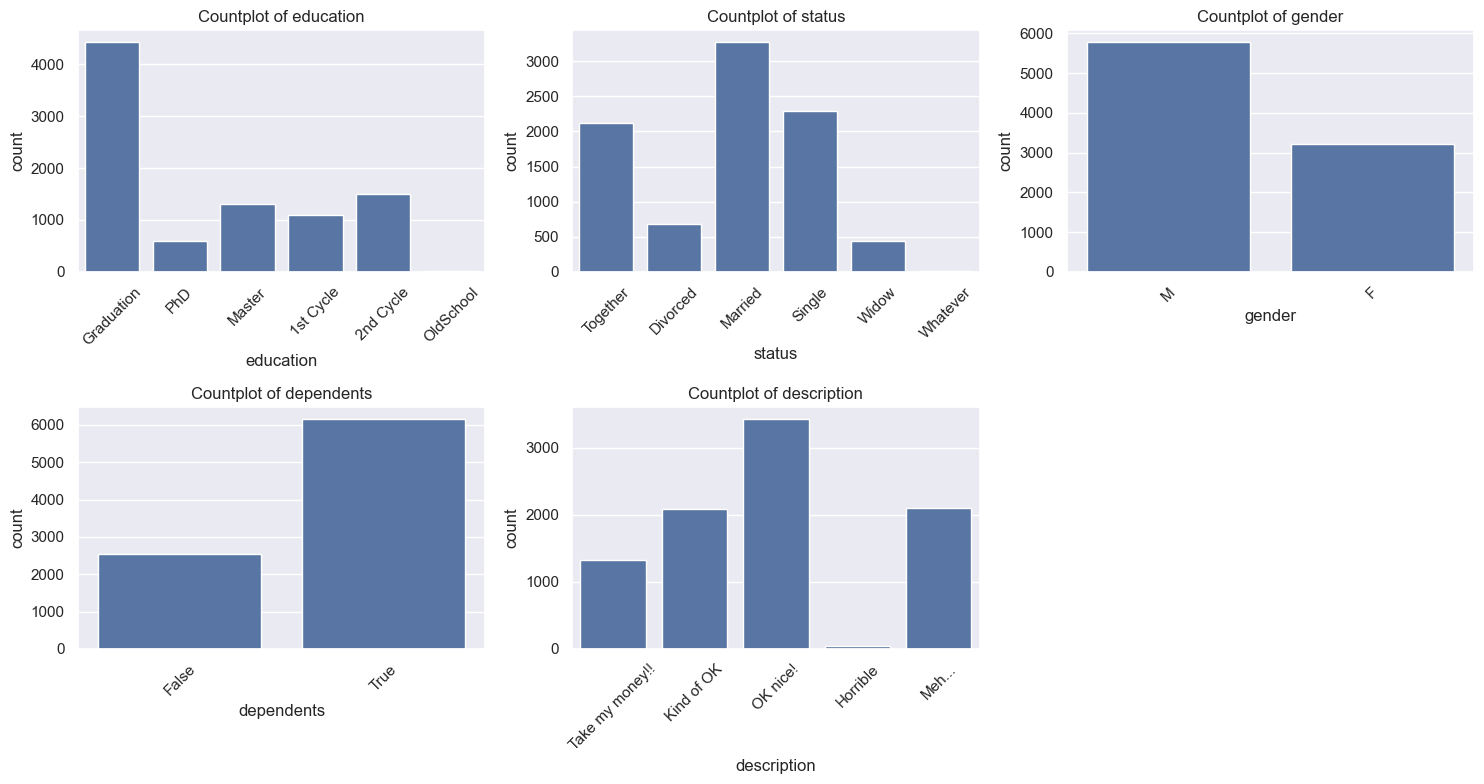

In [25]:
cols = 3
rows = math.ceil(len(categorical) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(categorical):
    sns.countplot(x=df[feature].dropna(), ax=axes[i], legend=False)
    axes[i].set_title(f"Countplot of {feature}")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Sometimes we have strange values that could be considered missing values, such as "?", "-", ".", etc.

In [71]:
# Example of doing so with education
df["education"] = df["education"].replace("", np.nan)

## Incoherences

#### Incoherence 1

Let's assume that the minimum age to be a customer at the store is 15 years old

In [27]:
df[df["birth_year"] >= datetime.now().year - 15]

,id,birth_year,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description


In [28]:
datetime.now().year - df["birth_year"].max()

np.int64(29)

#### Incoherence 2

Having more than 100% of purchases online.

In [29]:
df[df["per_net_purchase"] > 100]

,id,birth_year,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description


In [30]:
df["per_net_purchase"].max()

np.int64(88)

We could use the following to change values bigger than 100:

In [31]:
df.loc[df["per_net_purchase"] > 100, "per_net_purchase"] = 100

## Removing Outliers

We are trying remove only the data points that represent noise, values that do not provide meaningful information or that could distort the analysis.

However, it’s important not to remove too much data, as doing so can introduce sampling bias and information loss, making the remaining dataset less representative of the population.

As a general guideline, removing about 1–3% of the data is often reasonable. In some cases, removing up to 5% may be acceptable, depending on the dataset and the context of the analysis.

### Manual Filters

By examining the boxplots, we can identify approximate threshold values that may indicate potential outliers.

In [32]:
filters1 = (
    (df["house_keeping"]<=50)
    &
    (df["kitchen"]<=40)
    &
    (df["toys"]<=35)
    &
    (df["rcn"]<=450)
    &
    (df["education"]!="OldSchool")
    &
    (df["status"]!="Whatever")
)

df_1 = df[filters1].copy()

print("Percentage of data removed:", (len(df) - len(df_1)) / len(df) * 100, "%")

Percentage of data removed: 3.1340297843965326 %


### Z-Score

The Z-score measures how many standard deviations a data point is from the mean:

$$
z = \frac{x - \mu}{\sigma}
$$

The standard deviation measures how spread out the data is, and is calculated as:

$$
\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2}
$$

A data point is considered an outlier if:

$$
|z| \ge 3
$$

In [33]:
z_scores = np.abs(stats.zscore(df[numerical], nan_policy="omit"))

filters2 = (z_scores < 3).all(axis=1)

df_2 = df[filters2].copy()

print("Percentage of data removed:", (len(df) - len(df_2)) / len(df) * 100, "%")

Percentage of data removed: 9.135363414092021 %


### Interquartile Range (IQR)

We use the first (Q1) and third (Q3) quartiles to calculate the Interquartile Range (IQR):

$$
\text{IQR} = Q3 - Q1
$$

Any value is considered an outlier if it lies outside the following range:

$$
[\, Q1 - 1.5 \times \text{IQR}, \; Q3 + 1.5 \times \text{IQR} \,]
$$

In [34]:
Q1 = df[numerical].quantile(0.25)
Q3 = df[numerical].quantile(0.75)
IQR = Q3 - Q1

upper_lim = Q3 + 1.5 * IQR
lower_lim = Q1 - 1.5 * IQR

filters3 = ((df[numerical] >= lower_lim) & (df[numerical] <= upper_lim)).all(axis=1)

df_3 = df[filters3].copy()

print("Percentage of data removed:", (len(df) - len(df_3)) / len(df) * 100, "%")


Percentage of data removed: 18.048455212269392 %


### Combinations

Finally, we can combine the different definitions of outliers to create a more robust detection approach. 

In this case, a data point will only be considered an outlier if it is identified as such by all three previous methods.

In [35]:
df_4 = df[filters1 | filters2 | filters3].copy()

print("Percentage of data removed:", (len(df) - len(df_4)) / len(df) * 100, "%")

Percentage of data removed: 2.7339408757501666 %


In [36]:
df = df_4.copy()

In [37]:
df.shape

(8752, 17)

## Data Normalization

The goal of data normalization is to bring all features onto a common scale.

This is crucial to prevent models from becoming biased toward variables with larger numerical ranges, particularly in distance-based algorithms, where scale differences can heavily influence results.

Normalization also facilitates meaningful comparisons between features.

### MinMax Scaling

The Min–Max Scaling technique rescales each feature so that all values fall within 0 and 1.  
Here, 0 represents the minimum value of the feature and 1 represents the maximum value.

$$
x' = \frac{x - x_{\\min}}{x_{\\max} - x_{\\min}}
$$

In [38]:
df_minmax = df.copy()

In [39]:
minMaxScaler = MinMaxScaler()
df_minmax[numerical] = minMaxScaler.fit_transform(df_minmax[numerical])

In [40]:
df_minmax.head()

,id,birth_year,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description
0,0,0.166667,0.618413,0.535714,0.146667,0.458306,0.367347,0.125,0.589041,0.285714,0.06,False,0.178571,M,Graduation,Together,Take my money!!
1,1,0.000000,0.788675,0.517857,0.013333,0.502626,0.551020,0.025,0.506849,0.114286,0.04,False,0.059524,F,PhD,Divorced,Take my money!!
2,2,0.900000,0.140429,0.142857,0.153333,0.012475,0.316327,0.475,0.315068,0.028571,0.48,True,0.654762,M,Graduation,Married,Kind of OK
3,3,0.316667,0.639763,0.410714,0.022222,0.289560,0.602041,0.250,0.246575,0.171429,0.10,True,0.369048,F,Master,NaN,OK nice!
4,4,0.316667,0.626604,0.500000,0.057778,0.371635,0.591837,0.125,0.369863,0.114286,0.08,True,0.357143,F,Graduation,Together,Take my money!!


### Standard Scaling

Similar to the Z-Score method, Standard Scaling transforms each feature so that the new values have a mean of 0 and a standard deviation of 1.  

$$
x' = \frac{x - \mu}{\sigma}
$$

In [41]:
df_standard = df.copy()

In [42]:
standardScaler = StandardScaler()
df_standard[numerical] = standardScaler.fit_transform(df_standard[numerical])

In [43]:
df_standard.head()

,id,birth_year,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description
0,0,-1.142749,0.731451,1.182422,0.156818,1.181465,-0.622818,-0.241055,1.219611,0.500639,-0.497063,False,-1.248444,M,Graduation,Together,Take my money!!
1,1,-1.729510,1.547839,1.090662,-0.968894,1.389779,0.161503,-0.789851,0.743205,-0.372768,-0.630479,False,-1.789518,F,PhD,Divorced,Take my money!!
2,2,1.438999,-1.560427,-0.836289,0.213103,-0.914012,-0.840685,1.679733,-0.368409,-0.809471,2.304673,True,0.915850,M,Graduation,Married,Kind of OK
3,3,-0.614664,0.833825,0.540105,-0.893847,0.388332,0.379370,0.444941,-0.765414,-0.081632,-0.230231,True,-0.382727,F,Master,NaN,OK nice!
4,4,-0.614664,0.770727,0.998903,-0.593657,0.774097,0.335797,-0.241055,-0.050805,-0.372768,-0.363647,True,-0.436834,F,Graduation,Together,Take my money!!


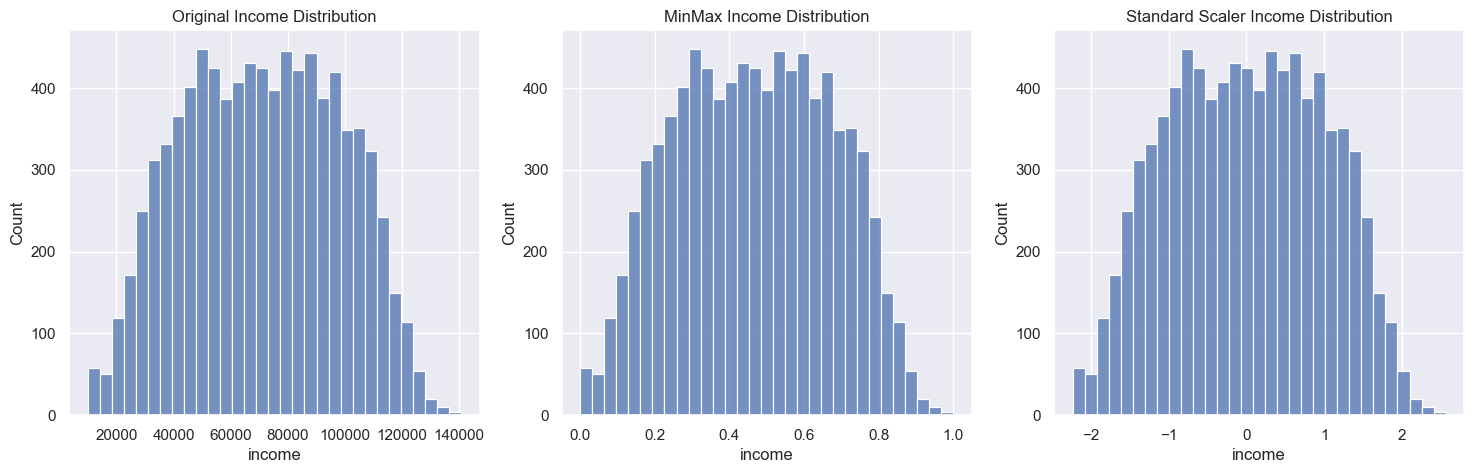

In [44]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.title('Original Income Distribution')
sns.histplot(df["income"])

plt.subplot(1, 3, 2)
plt.title('MinMax Income Distribution')
sns.histplot(df_minmax["income"])

plt.subplot(1, 3, 3)
plt.title('Standard Scaler Income Distribution')
sns.histplot(df_standard["income"])

plt.show()

In [45]:
df = df_minmax.copy()

## Data Imputation

In [46]:
df.isna().sum()

id                    0
birth_year            0
income               46
frq                   0
rcn                   0
mnt                   0
clothes               0
kitchen               0
small_appliances      0
toys                  0
house_keeping         0
dependents          276
per_net_purchase      0
gender                0
education            44
status              171
description           0
dtype: int64

### Central Tendency Measures

We can simply use the mean, median and mode to fill the missing values.

In [47]:
df_central = df.copy()

In [48]:
df_central[numerical].mean()

birth_year          0.491259
income              0.465865
frq                 0.305606
rcn                 0.128093
mnt                 0.206939
clothes             0.513199
kitchen             0.168924
small_appliances    0.378628
toys                0.187451
house_keeping       0.134513
per_net_purchase    0.453256
dtype: float64

In [49]:
df_central[numerical].median()

birth_year          0.483333
income              0.467725
frq                 0.267857
rcn                 0.115556
mnt                 0.126067
clothes             0.520408
kitchen             0.100000
small_appliances    0.369863
toys                0.114286
house_keeping       0.080000
per_net_purchase    0.488095
dtype: float64

In [50]:
df_central[categorical].mode().loc[0]

education      Graduation
status            Married
gender                  M
dependents           True
description      OK nice!
Name: 0, dtype: object

In [51]:
df_central[numerical] = df_central[numerical].fillna(df_central[numerical].median())
df_central[categorical] = df_central[categorical].fillna(df_central[categorical].mode().loc[0])

In [52]:
df_central.isna().sum()

id                  0
birth_year          0
income              0
frq                 0
rcn                 0
mnt                 0
clothes             0
kitchen             0
small_appliances    0
toys                0
house_keeping       0
dependents          0
per_net_purchase    0
gender              0
education           0
status              0
description         0
dtype: int64

### K-Nearest Neighbors (KNN)

We will use distances as a similarity criterion and, based on the nearest data points around a missing value, we will infer a more "correct" value to impute.

KNN can also take advantage of weights:
- uniform = every neighbor contributes equally
- distance = contribution is inversely proportional to distance

In [53]:
df_knn = df.copy()

In [ ]:
imputer = KNNImputer(n_neighbors=5, weights="uniform")

In [55]:
df_knn[numerical] = imputer.fit_transform(df_knn[numerical])

In [56]:
df_knn[numerical].isna().sum()

birth_year          0
income              0
frq                 0
rcn                 0
mnt                 0
clothes             0
kitchen             0
small_appliances    0
toys                0
house_keeping       0
per_net_purchase    0
dtype: int64

We can simply use the mode to fill the categorical features.

In [57]:
df_knn[categorical] = df_knn[categorical].fillna(df_knn[categorical].mode().loc[0])

In [58]:
df_knn.isna().sum()

id                  0
birth_year          0
income              0
frq                 0
rcn                 0
mnt                 0
clothes             0
kitchen             0
small_appliances    0
toys                0
house_keeping       0
dependents          0
per_net_purchase    0
gender              0
education           0
status              0
description         0
dtype: int64

In [59]:
df = df_knn.copy()

## Feature Engineering

In here, we focus on creating and transforming features to improve model performance. 

Feature engineering involves generating new variables or modifying existing ones to better capture the underlying patterns in the data.

To make these newly created variables easier to interpret, we will temporarily reverse the normalization process before performing feature engineering, and then reapply normalization afterward.

In [60]:
df[numerical] = minMaxScaler.inverse_transform(df[numerical])
df.head()

,id,birth_year,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description
0,0,1946.0,90782.0,33.0,66.0,1402.0,37.0,5.0,44.0,10.0,3.0,False,19.0,M,Graduation,Together,Take my money!!
1,1,1936.0,113023.0,32.0,6.0,1537.0,55.0,1.0,38.0,4.0,2.0,False,9.0,F,PhD,Divorced,Take my money!!
2,2,1990.0,28344.0,11.0,69.0,44.0,32.0,19.0,24.0,1.0,24.0,True,59.0,M,Graduation,Married,Kind of OK
3,3,1955.0,93571.0,26.0,10.0,888.0,60.0,10.0,19.0,6.0,5.0,True,35.0,F,Master,Married,OK nice!
4,4,1955.0,91852.0,31.0,26.0,1138.0,59.0,5.0,28.0,4.0,4.0,True,34.0,F,Graduation,Together,Take my money!!


We can now create/transform our variables.

In [61]:
df["age"] = datetime.now().year - df["birth_year"]

df["spent_online"] = (df["per_net_purchase"] / 100) * df["mnt"]

df.head()

,id,birth_year,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description,age,spent_online
0,0,1946.0,90782.0,33.0,66.0,1402.0,37.0,5.0,44.0,10.0,3.0,False,19.0,M,Graduation,Together,Take my money!!,79.0,266.38
1,1,1936.0,113023.0,32.0,6.0,1537.0,55.0,1.0,38.0,4.0,2.0,False,9.0,F,PhD,Divorced,Take my money!!,89.0,138.33
2,2,1990.0,28344.0,11.0,69.0,44.0,32.0,19.0,24.0,1.0,24.0,True,59.0,M,Graduation,Married,Kind of OK,35.0,25.96
3,3,1955.0,93571.0,26.0,10.0,888.0,60.0,10.0,19.0,6.0,5.0,True,35.0,F,Master,Married,OK nice!,70.0,310.80
4,4,1955.0,91852.0,31.0,26.0,1138.0,59.0,5.0,28.0,4.0,4.0,True,34.0,F,Graduation,Together,Take my money!!,70.0,386.92


Don't forget to add any new features to our numerical / categorical lists.

In [62]:
numerical.append("age")
numerical.append("spent_online")

Finally, we will apply the MinMax again.

In [63]:
df[numerical] = minMaxScaler.fit_transform(df[numerical])
df.head()

,id,birth_year,income,frq,rcn,mnt,clothes,kitchen,small_appliances,toys,house_keeping,dependents,per_net_purchase,gender,education,status,description,age,spent_online
0,0,0.166667,0.618413,0.535714,0.146667,0.458306,0.367347,0.125,0.589041,0.285714,0.06,False,0.178571,M,Graduation,Together,Take my money!!,0.833333,0.186504
1,1,0.000000,0.788675,0.517857,0.013333,0.502626,0.551020,0.025,0.506849,0.114286,0.04,False,0.059524,F,PhD,Divorced,Take my money!!,1.000000,0.095912
2,2,0.900000,0.140429,0.142857,0.153333,0.012475,0.316327,0.475,0.315068,0.028571,0.48,True,0.654762,M,Graduation,Married,Kind of OK,0.100000,0.016413
3,3,0.316667,0.639763,0.410714,0.022222,0.289560,0.602041,0.250,0.246575,0.171429,0.10,True,0.369048,F,Master,Married,OK nice!,0.683333,0.217930
4,4,0.316667,0.626604,0.500000,0.057778,0.371635,0.591837,0.125,0.369863,0.114286,0.08,True,0.357143,F,Graduation,Together,Take my money!!,0.683333,0.271783


## Feature Selection

### Pearson Correlation

The Pearson correlation coefficient measures the strength and direction of a linear relationship between two variables. This coefficient ranges from -1 to 1.

A negative value indicates a negative slope, when one feature increases the other decreases.

A positive value indicates a positive slope, when a feature increases the other increases.

The closer the value is to -1 or 1, the closer the relationship is to a straight line.

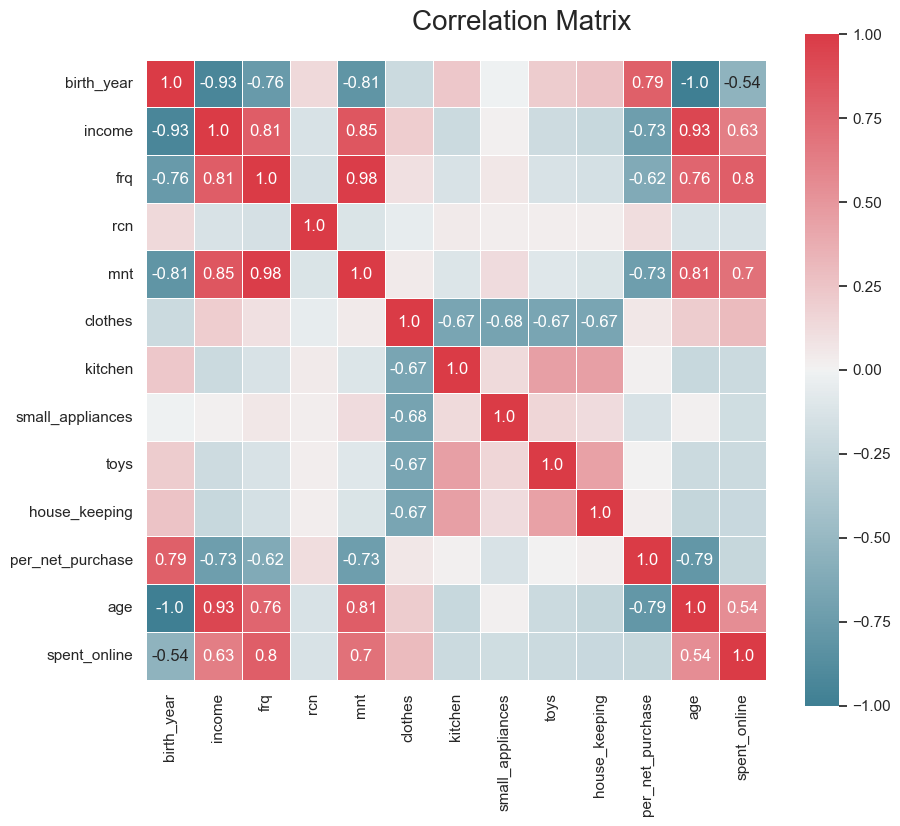

In [64]:
fig = plt.figure(figsize=(10,8))

corr = np.round(df[numerical].corr(method="pearson"), decimals=2)

mask_annot = np.absolute(corr.values) >= 0.5
annot = np.where(mask_annot, corr.values, np.full(corr.shape,""))

sns.heatmap(data=corr, annot=annot, cmap=sns.diverging_palette(220, 10, as_cmap=True),
            fmt='s', vmin=-1, vmax=1, center=0, square=True, linewidths=.5)

fig.subplots_adjust(top=0.95)
fig.suptitle("Correlation Matrix", fontsize=20)

plt.show()

### Redundancy Vs. Relevancy

Maximize relevancy = Select features that will be relevant for clustering that provide unique information. We want features that meaningfully separate the data points.

Minimize redundancy = Avoid including features that are strongly correlated with each other. Features that aren't correlated with any other features are often also not relevant.

In [65]:
df_selection = df.copy()

In [66]:
df_selection = df_selection.drop(columns=["mnt", "birth_year", "age"])
numerical.remove("mnt")
numerical.remove("birth_year")
numerical.remove("age")

## One-Hot Encoding

For categorical features, we will apply one-hot encoding to convert them into numerical form. This technique creates a new binary column for each category.

This is necessary due to the fact that most machine learning models can only interpret numerical data.

In [67]:
def get_ohc_df(df, feats):
  ohc = OneHotEncoder(sparse_output=False, drop="first")
  ohc_feat = ohc.fit_transform(df[feats])
  ohc_feat_names = ohc.get_feature_names_out()
  ohc_df = pd.DataFrame(ohc_feat, index=df.index, columns=ohc_feat_names)

  df_ohc = pd.concat([df, ohc_df], axis=1)

  return df_ohc, ohc

In [68]:
df_encoding, ohc = get_ohc_df(df_selection, categorical)

In [69]:
ohc.get_feature_names_out()

array(['education_2nd Cycle', 'education_Graduation', 'education_Master',
       'education_OldSchool', 'education_PhD', 'status_Married',
       'status_Single', 'status_Together', 'status_Whatever',
       'status_Widow', 'gender_M', 'dependents_1.0',
       'description_Kind of OK', 'description_Meh...',
       'description_OK nice!', 'description_Take my money!!'],
      dtype=object)

In [70]:
df_encoding

,id,income,frq,rcn,clothes,kitchen,small_appliances,toys,house_keeping,dependents,...,status_Single,status_Together,status_Whatever,status_Widow,gender_M,dependents_1.0,description_Kind of OK,description_Meh...,description_OK nice!,description_Take my money!!
0,0,0.618413,0.535714,0.146667,0.367347,0.125,0.589041,0.285714,0.06,False,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,1,0.788675,0.517857,0.013333,0.551020,0.025,0.506849,0.114286,0.04,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2,0.140429,0.142857,0.153333,0.316327,0.475,0.315068,0.028571,0.48,True,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
3,3,0.639763,0.410714,0.022222,0.602041,0.250,0.246575,0.171429,0.10,True,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,4,0.626604,0.500000,0.057778,0.591837,0.125,0.369863,0.114286,0.08,True,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8992,8992,0.592515,0.392857,0.002222,0.561224,0.200,0.356164,0.228571,0.02,True,...,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
8993,8993,0.645857,0.446429,0.002222,0.683673,0.125,0.273973,0.085714,0.08,True,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
8994,8994,0.368382,0.160714,0.013333,0.530612,0.150,0.369863,0.200000,0.12,True,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
8995,8995,0.339070,0.464286,0.160000,0.408163,0.275,0.479452,0.028571,0.22,False,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
